In [1]:
import pandas as pd
import lightgbm as lgb
import shap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

/home/rigonzal/miniconda3/envs/genv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import matplotlib
matplotlib.__version__

'3.8.4'

In [3]:
shap.__version__

'0.46.0'

# 0.Config

In [51]:
path_fe = "../../outputs/fe/"
path_proc = "../../outputs/proc/"

# 1. Data

In [52]:
df_mdt = pd.read_parquet(f"{path_fe}train_all_joined_fe_delta_years=4.parquet")
df_mdt.shape

(1877383, 71)

In [53]:
df_dated = pd.read_csv(f"{path_fe}DateDimension.csv")
df_dated.shape

(3287, 5)

In [54]:
df_mdt

,unique_key,month,day,crsdeptime,avg_delay_route_last_30d,avg_delay_airline_dest_last_14d,rank,air_safety__general_aviation_fatalities,us_airline_traffic__total__seasonally_adjusted,us_airline_traffic__international__seasonally_adjusted,...,deststate_NJ,deststate_NY,operating_airline_9E,operating_airline_AA,operating_airline_B6,operating_airline_DL,operating_airline_UA,operating_airline_YX,arrdelay,aircraft_service_attendants_and_transportation_workers_all_other
0,2021-10-11-900-DL-JFK-SEA,2021-10-01,11,900,4.235000,3.562500,15.0,20.0,62000000.0,5460000.0,...,0,0,0,0,0,1,0,0,-26.0,NaN
1,2021-03-17-1140-AA-CLT-LGA,2021-03-01,17,1140,-16.160000,-15.358268,22.0,25.0,32100000.0,2600000.0,...,0,1,0,1,0,0,0,0,-27.0,NaN
2,2020-02-13-1215-UA-SAN-EWR,2020-02-01,13,1215,15.586538,6.311910,8.0,28.0,80600000.0,9730000.0,...,1,0,0,0,0,0,1,0,-9.0,33430.0
3,2019-06-24-1150-DL-LGA-MCO,2019-06-01,24,1150,3.063253,-9.069930,28.0,48.0,75930000.0,9540000.0,...,0,0,0,0,0,1,0,0,-25.0,34940.0
4,2018-09-06-1235-MQ-BWI-JFK,2018-09-01,6,1235,NaN,NaN,18.0,54.0,74400000.0,9270000.0,...,0,1,0,0,0,0,0,0,-4.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1877378,2019-07-14-1105-OO-LGA-DSM,2019-07-01,14,1105,-5.382979,NaN,28.0,71.0,77480000.0,9590000.0,...,0,0,0,0,0,0,0,0,-31.0,34940.0
1877379,2019-09-10-1230-UA-SNA-EWR,2019-09-01,10,1230,14.088608,25.147242,NaN,40.0,77020000.0,9680000.0,...,1,0,0,0,0,0,1,0,-19.0,34940.0
1877380,2020-07-21-1500-DL-LGA-MSP,2020-07-01,21,1500,-16.036585,-11.347826,26.0,31.0,15140000.0,350000.0,...,0,0,0,0,0,1,0,0,-13.0,33430.0
1877381,2018-07-13-1840-C5-AVP-EWR,2018-07-01,13,1840,32.111111,37.038321,NaN,41.0,74370000.0,9240000.0,...,1,0,0,0,0,0,0,0,7.0,NaN


In [55]:
df_dated

,Date,DayShort,isUSA_Holiday,isUSA_Workingday,isLongweekend
0,01/01/18,Mon,1,0,1
1,01/02/18,Tue,0,1,0
2,01/03/18,Wed,0,1,0
3,01/04/18,Thu,0,1,0
4,01/05/18,Fri,0,1,0
...,...,...,...,...,...
3282,12/27/26,Sun,0,0,1
3283,12/28/26,Mon,0,1,1
3284,12/29/26,Tue,0,1,0
3285,12/30/26,Wed,0,1,0


# 2. Processing

In [56]:
from datetime import datetime

In [57]:
def arrival_category(row):

    if row <=15:
        return "On-Time"
    elif row <=45:
        return "Late"
    else:
        return "Very Late"

In [58]:
def change_date(row):
    date_obj = datetime.strptime(row, "%m/%d/%y")
    formatted_date = date_obj.strftime("%Y-%m-%d")
    return formatted_date

In [59]:
df_dated["Date"] = df_dated["Date"].apply(lambda x: change_date(x))

In [60]:
df_mdt["dt_obj"] = df_mdt["month"].astype(str).str.slice(0,8)  + df_mdt["day"].astype(str)
df_mdt["dt_obj"] = pd.to_datetime(df_mdt["dt_obj"])
df_mdt["dt"] = df_mdt["dt_obj"].dt.date.astype(str)
df_mdt["day_of_week"] = df_mdt["dt_obj"].dt.dayofweek
df_mdt["month"] = df_mdt["dt_obj"].dt.month

In [61]:
df_mdt['week_of_month'] = df_mdt['dt_obj'].apply(lambda d: (d.day - 1) // 7 + 1)

In [62]:
df_mdt["hour"] = df_mdt["crsdeptime"].astype(str).str.slice(0,-2).replace("",-1).astype(int)

In [63]:
df_mdt["hour_timerange_0_5"] = (df_mdt["hour"]>=0)&(df_mdt["hour"]<=5).astype(int)
df_mdt["hour_timerange_6_11"] = (df_mdt["hour"]>=6)&(df_mdt["hour"]<=11).astype(int)
df_mdt["hour_timerange_12_17"] = (df_mdt["hour"]>=12)&(df_mdt["hour"]<=17).astype(int)
df_mdt["hour_timerange_18_23"] = (df_mdt["hour"]>=18)&(df_mdt["hour"]<=23).astype(int)

In [64]:
df_mdt["month_range_1_3"] = (df_mdt["month"]>=1)&(df_mdt["month"]<=3).astype(int)
df_mdt["month_range_4_6"] = (df_mdt["month"]>=4)&(df_mdt["month"]<=6).astype(int)
df_mdt["month_range_7_9"] = (df_mdt["month"]>=7)&(df_mdt["month"]<=9).astype(int)
df_mdt["month_range_10_12"] = (df_mdt["month"]>=10)&(df_mdt["month"]<=12).astype(int)

In [65]:
# Merge features date dimension 
df_mdt = df_mdt.merge(df_dated, left_on="dt", right_on="Date", how="left")

In [66]:
df_mdt.head()

,unique_key,month,day,crsdeptime,avg_delay_route_last_30d,avg_delay_airline_dest_last_14d,rank,air_safety__general_aviation_fatalities,us_airline_traffic__total__seasonally_adjusted,us_airline_traffic__international__seasonally_adjusted,...,hour_timerange_18_23,month_range_1_3,month_range_4_6,month_range_7_9,month_range_10_12,Date,DayShort,isUSA_Holiday,isUSA_Workingday,isLongweekend
0,2021-10-11-900-DL-JFK-SEA,10,11,900,4.235000,3.562500,15.0,20.0,62000000.0,5460000.0,...,False,False,False,False,True,2021-10-11,Mon,1,0,1
1,2021-03-17-1140-AA-CLT-LGA,3,17,1140,-16.160000,-15.358268,22.0,25.0,32100000.0,2600000.0,...,False,True,False,False,False,2021-03-17,Wed,0,1,0
2,2020-02-13-1215-UA-SAN-EWR,2,13,1215,15.586538,6.311910,8.0,28.0,80600000.0,9730000.0,...,False,True,False,False,False,2020-02-13,Thu,0,1,0
3,2019-06-24-1150-DL-LGA-MCO,6,24,1150,3.063253,-9.069930,28.0,48.0,75930000.0,9540000.0,...,False,False,True,False,False,2019-06-24,Mon,0,1,0
4,2018-09-06-1235-MQ-BWI-JFK,9,6,1235,NaN,NaN,18.0,54.0,74400000.0,9270000.0,...,False,False,False,True,False,2018-09-06,Thu,0,1,0


In [67]:
# Create binary target
df_mdt["arrival_category"] = df_mdt["arrdelay"].apply(arrival_category)
df_mdt = df_mdt.drop(["arrdelay"], axis=1)
df_mdt["arrival_category"].value_counts(normalize=True)

arrival_category
On-Time      0.785923
Very Late    0.113150
Late         0.100927
Name: proportion, dtype: float64

In [68]:
df_mdt.columns[df_mdt.dtypes=="object"]

Index(['unique_key', 'dt', 'Date', 'DayShort', 'arrival_category'], dtype='object')

In [69]:
# 🔹 Define features and target
y = df_mdt["arrival_category"].values.copy()
df_mdt = df_mdt.drop(columns=['unique_key', 'dt', "dt_obj", 'Date', 'DayShort', "arrival_category"])

In [70]:
X_train, X_val, y_train, y_val = train_test_split(df_mdt, y, stratify=y, test_size=0.1, random_state=42)

In [71]:
pd.Series(y_train).value_counts(normalize=True)

On-Time      0.785924
Very Late    0.113150
Late         0.100927
Name: proportion, dtype: float64

In [72]:
pd.Series(y_val).value_counts(normalize=True)

On-Time      0.785921
Very Late    0.113152
Late         0.100927
Name: proportion, dtype: float64

# 3. Train

In [73]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report

In [74]:
param_dist = {
    "num_leaves": [15, 31, 63, 127],
    "learning_rate": [0.005, 0.01, 0.05, 0.1],
    "n_estimators": [100, 200, 500],
    "max_depth": [-1, 5, 10, 15],
    "min_child_samples": [10, 20, 50],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}

In [82]:
model = lgb.LGBMClassifier(objective="multiclass",
                           class_weight='balanced',
                             num_class=len(np.unique(y)),
                               verbose=-1,
                               num_leaves=20,
                               n_estimators=100,
                               max_depth=5,
                               colsample_bytree=0.8,
                               lambda_l1=1)

model.fit(X_train, y_train)

LGBMClassifier(class_weight='balanced', colsample_bytree=0.8, lambda_l1=1,
               max_depth=5, num_class=3, num_leaves=20, objective='multiclass',
               verbose=-1)

# 4. Metrics

In [83]:
# 🔹 Predictions & Metrics
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

#y_train_pred_labels = np.argmax(y_train_pred, axis=1)
#y_val_pred_labels = np.argmax(y_val_pred, axis=1)


print(classification_report(y_train, y_train_pred))

print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

        Late       0.15      0.31      0.20    170530
     On-Time       0.90      0.61      0.73   1327931
   Very Late       0.27      0.58      0.36    191183

    accuracy                           0.58   1689644
   macro avg       0.44      0.50      0.43   1689644
weighted avg       0.75      0.58      0.63   1689644

              precision    recall  f1-score   support

        Late       0.15      0.31      0.20     18948
     On-Time       0.90      0.61      0.73    147548
   Very Late       0.26      0.58      0.36     21243

    accuracy                           0.58    187739
   macro avg       0.44      0.50      0.43    187739
weighted avg       0.75      0.58      0.63    187739



# Feature importance SHAPs analysis

In [84]:
explainer = shap.Explainer(model)
shap_values = explainer(X_val)

In [85]:
shap_values[:, :, 0].shape

(187739, 83)

Class 0 SHAP summary:


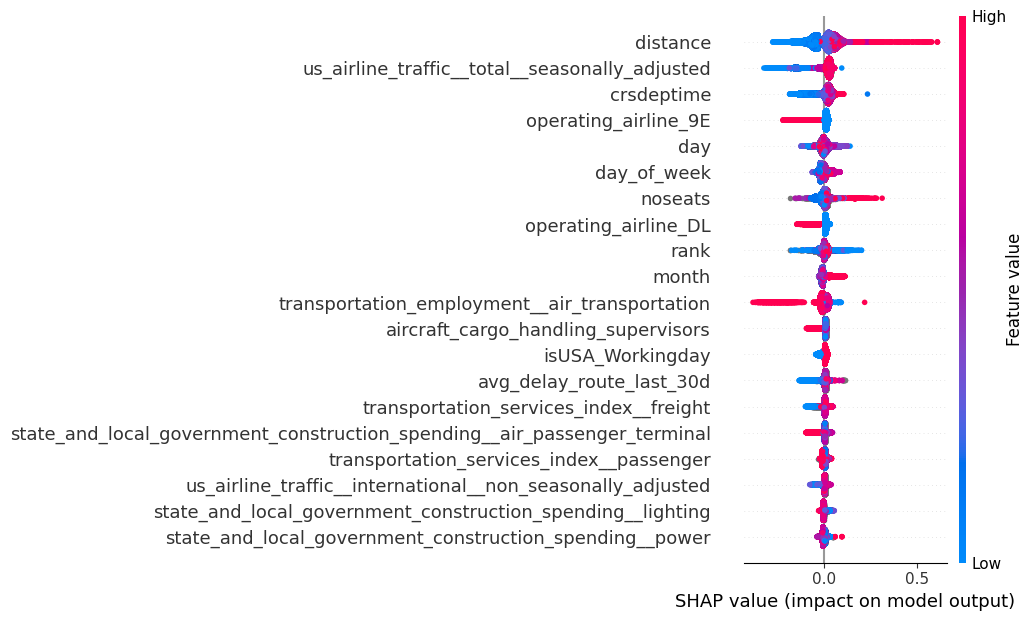

Class 1 SHAP summary:


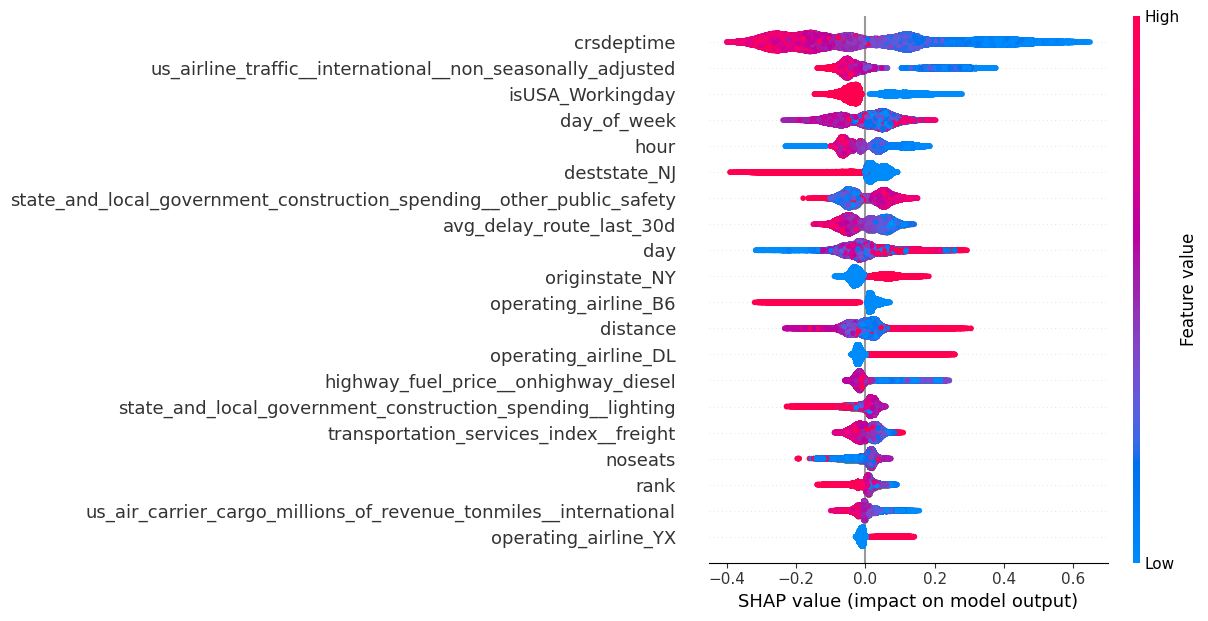

Class 2 SHAP summary:


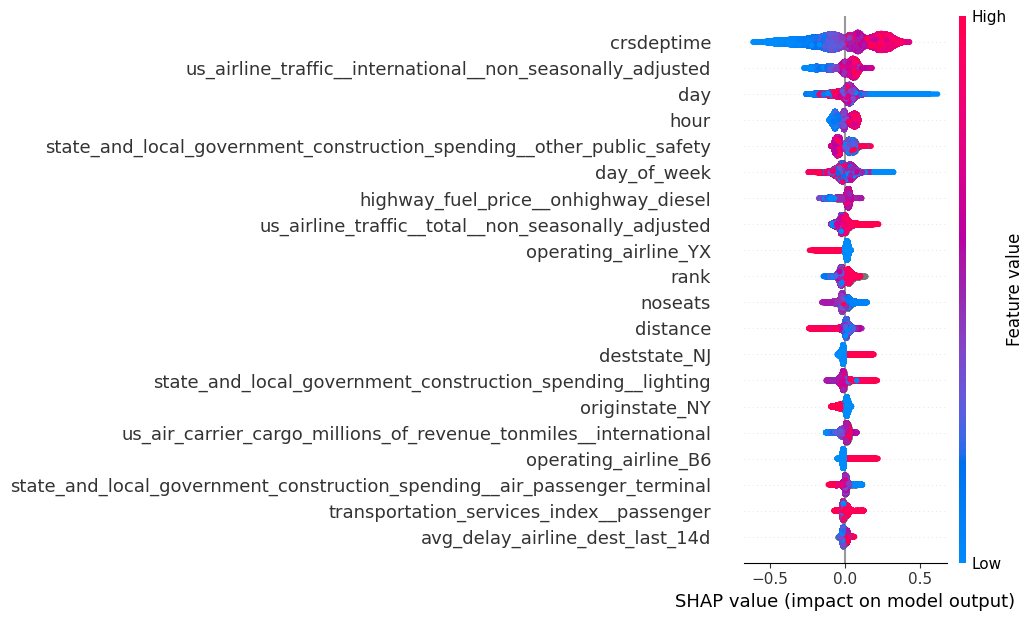

In [86]:
for i in range(shap_values.shape[2]):
    print(f"Class {i} SHAP summary:")
    fig = shap.summary_plot(shap_values[:,:,i], X_val, show=False)
    w, h = plt.gcf().get_size_inches()
    plt.gcf().set_size_inches(w*7, w*0.75)
    plt.show()

# 5. Final metrics

In [32]:
df_mdt = pd.read_parquet(f"{path_fe}val_all_joined_fe_delta_years=4.parquet")
df_mdt.shape

(469344, 71)

In [33]:
def arrival_category(row):

    if row <=15:
        return "On-Time"
    elif row <=45:
        return "Late"
    else:
        return "Very Late"

In [34]:
# Create binary target
df_mdt["arrival_category"] = df_mdt["arrdelay"].apply(arrival_category)
df_mdt = df_mdt.drop(["arrdelay"], axis=1)
df_mdt["arrival_category"].value_counts(normalize=True)

arrival_category
On-Time      0.785925
Very Late    0.113149
Late         0.100926
Name: proportion, dtype: float64

In [35]:
df_mdt["dt_obj"] = df_mdt["month"].astype(str).str.slice(0,8)  + df_mdt["day"].astype(str)
df_mdt["dt_obj"] = pd.to_datetime(df_mdt["dt_obj"])
df_mdt["day_of_week"] = df_mdt["dt_obj"].dt.dayofweek
df_mdt["month"] = df_mdt["dt_obj"].dt.month

In [36]:
# 🔹 Define features and target
y = df_mdt["arrival_category"].values.copy()
df_mdt = df_mdt.drop(columns=["unique_key","arrival_category", "dt_obj"])

In [39]:
# 🔹 Predictions & Metrics
y_val_pred = model.predict(df_mdt)

print(classification_report(y, y_val_pred))

              precision    recall  f1-score   support

        Late       0.14      0.30      0.19     47369
     On-Time       0.90      0.61      0.73    368869
   Very Late       0.26      0.58      0.36     53106

    accuracy                           0.58    469344
   macro avg       0.44      0.50      0.43    469344
weighted avg       0.75      0.58      0.63    469344

